# Naveen — Final Epoch-150 Task 3 Metrics

Evaluation and recording only: epoch 150, global step 45000, seed 171. Existing predictions and official FID/MiFID evidence are preserved. No training loops or image exports.


## Paths and deterministic policy

Project-relative paths; all sorted Monet and first 300 sorted Photos, with same-stem existing translations. Isolated dependencies and metric-only pretrained weights are inside the new final-metrics folder.


In [1]:
from pathlib import Path
import os, sys, random, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p/"naveen/src/models.py").is_file() and (p/"data/monet_jpg").is_dir())
FINAL_ROOT = ROOT/"naveen/outputs_repro/final_metrics_epoch150"
sys.path.insert(0,str(ROOT/"naveen/src"))
sys.path.insert(0,str(FINAL_ROOT/"packages_readable"))
os.environ["TORCH_HOME"] = str(FINAL_ROOT/"torch_cache")
os.environ["MPLCONFIGDIR"] = str(FINAL_ROOT/"runtime/matplotlib")
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm
from IPython.display import display
import final_epoch150_metrics as fm
SEED = 171
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = torchvision.models
print("Output:",fm.OUT_REL.as_posix(),"Device:",device,"Seed:",SEED,"Cap:",fm.CAP)


Output: naveen/outputs_repro/final_metrics_epoch150 Device: cuda Seed: 171 Cap: 300


## Verify existing inputs, checkpoint and records

Verify every stored image count, filename and 256×256 RGB mode. Confirm epoch/step/seed, official CSV values, existing parameter-count output and complete 1–150 training history. Hash protected artifacts before metric computation.


In [2]:
ctx = fm.prepare_evaluation(ROOT)
display(pd.DataFrame([ctx["official_scores"]]))
print("Checkpoint:",ctx["checkpoint"],"SHA256:",ctx["checkpoint_sha256"])
print("History epochs:",len(ctx["history"]),"Global step:",int(ctx["epoch150"]["global_step"]))


Verified real_A: 300 existing images; selected 300.
Verified real_B: 2000/7038
Verified real_B: 4000/7038
Verified real_B: 6000/7038
Verified real_B: 7038 existing images; selected 300.
Verified gen_A2B: 300 existing images; selected 300.
Verified gen_B2A: 2000/7038
Verified gen_B2A: 4000/7038
Verified gen_B2A: 6000/7038
Verified gen_B2A: 7038 existing images; selected 300.
Protected evidence hashes: 4000 files
Protected evidence hashes: 8000 files
Protected evidence hashes: 12000 files
Protected evidence hashes: 16000 files
Protected evidence hashes: 20000 files
Checkpoint naveen/checkpoints_repro/repro_20261002T030447909094Z_57cacd34/epoch_150.pt: epoch 150, step 45000, seed 171.
Verified complete epochs 1–150, existing official scores, parameter-count evidence, and immutable inputs.
Checkpoint: naveen/checkpoints_repro/repro_20261002T030447909094Z_57cacd34/epoch_150.pt SHA256: 9cc42d24ca52fd53d3ba1b690c92a5fb0fd4eb8a27dfd087f86e030a3ae24152
History epochs: 150 Global step: 45000


,FID_A2B,MiFID_A2B,FID_B2A,MiFID_B2A,submission_FID,submission_MiFID
0,109.489139,0.431104,105.867864,0.413123,107.678501,0.422113


## Environment and GPU

Record exact package versions, CUDA/driver and evaluation-only model-weight hashes. Training VRAM is read separately from its existing CSV.


In [3]:
environment = fm.evaluation_environment(ctx)
print(json.dumps(environment,indent=2))


{
  "python": "3.12.15 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:14:50) [MSC v.1942 64 bit (AMD64)]",
  "packages": {
    "torch": "2.14.1+cu130",
    "torchvision": "0.29.1+cu130",
    "numpy": "2.5.2",
    "pandas": "3.0.6",
    "scipy": "1.18.1",
    "matplotlib": "3.11.2",
    "Pillow": "12.3.0",
    "lpips": "0.1.4",
    "pypdf": "6.19.0",
    "ipython": "9.17.1"
  },
  "cuda": "13.0",
  "seed": 171,
  "gpu": "NVIDIA GeForce RTX 4090",
  "GPU_total_GiB": 23.98779296875,
  "Inception": "torchvision Inception_V3_Weights.IMAGENET1K_V1; fc=Identity; 2048 pooled features",
  "Inception_weights_sha256": "0cc3c7bd75056d25e46cba549dc184522069b81e9787eff6df84f397bd52a5ef",
  "LPIPS": "lpips 0.1.4; net=alex; version=0.1; pretrained=True; pnet_rand=False; eval mode",
  "AlexNet_weights_sha256": "7be5be791159472b1fbf3c69796f7cb30dca7ad8466c2df70058c37116cdee02",
  "nvidia_driver": "610.60"
}


## Course protocol search and reuse

The assignment lists metrics and defines content cosine as input versus translation, but supplies no additional algorithm or LPIPS pairing. Task-2 classifier precision/recall is not substituted. Use the requested fallback protocols and retain course-search evidence.


In [4]:
reuse = {
 "searched":["naveen/src","reference","../../Downloads/DATA266-Lab1-Pair25-main.zip",
             "../../Downloads/DATA266_Lab1_Fall_2026.pdf","../task3_gpu/DATA266_Lab1_Fall_2026.pdf",
             "../../Downloads/CycleGAN_Training_Flow_Study_Guide.pdf"],
 "course_page":"DATA266_Lab1_Fall_2026.pdf, Task 3 metrics, page 9",
 "reused_exactly":{"feature_extraction":"Epoch-150 official instructor evaluator cell 5",
                  "generator":"naveen/src/models.py Generator",
                  "cycle_preprocessing":"naveen/src/dataset.py load_image(training=False)",
                  "parameters":"Existing executed step-18 notebook output",
                  "training":"Existing epochs CSV history"},
 "no_additional_course_algorithms_found":True,
 "LPIPS_pairing":"Real input vs cycle reconstruction; no paired target protocol supplied",
 "fallbacks":{"KID":"Unbiased degree-3 polynomial MMD",
              "precision_recall":"k=3 nearest-neighbor feature manifolds",
              "content_cosine":"Input vs same-filename existing translation"}}
fm.save_json(ctx,"manifests/protocol_search_and_reuse.json",reuse)
print(json.dumps(reuse,indent=2))
fm.metric_sanity_checks()


{
  "searched": [
    "naveen/src",
    "reference",
    "../../Downloads/DATA266-Lab1-Pair25-main.zip",
    "../../Downloads/DATA266_Lab1_Fall_2026.pdf",
    "../task3_gpu/DATA266_Lab1_Fall_2026.pdf",
    "../../Downloads/CycleGAN_Training_Flow_Study_Guide.pdf"
  ],
  "course_page": "DATA266_Lab1_Fall_2026.pdf, Task 3 metrics, page 9",
  "reused_exactly": {
    "feature_extraction": "Epoch-150 official instructor evaluator cell 5",
    "generator": "naveen/src/models.py Generator",
    "cycle_preprocessing": "naveen/src/dataset.py load_image(training=False)",
    "parameters": "Existing executed step-18 notebook output",
    "training": "Existing epochs CSV history"
  },
  "no_additional_course_algorithms_found": true,
  "LPIPS_pairing": "Real input vs cycle reconstruction; no paired target protocol supplied",
  "fallbacks": {
    "KID": "Unbiased degree-3 polynomial MMD",
    "precision_recall": "k=3 nearest-neighbor feature manifolds",
    "content_cosine": "Input vs same-filename e

## Exact instructor Inception extraction

The following definitions are copied verbatim from instructor cell 5. Extract 300×2048 features per set once; reuse them for KID, generative precision/recall and content cosine. FID/MiFID are not recomputed.


In [5]:
# Inception feature extractor
def get_inception_model():
    inception = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False
    )
    inception.fc = nn.Identity()
    inception.to(device)
    inception.eval()
    return inception

INCEPTION_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def load_batch(paths):
    imgs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        imgs.append(INCEPTION_TF(img))
    return torch.stack(imgs, dim=0)

@torch.no_grad()
def get_activations(model, image_paths, batch_size=32):
    feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Inception activations"):
        batch_paths = image_paths[i:i+batch_size]
        x = load_batch(batch_paths).to(device)
        f = model(x).detach().cpu().numpy()
        feats.append(f)
    return np.concatenate(feats, axis=0)
print("Exact instructor feature-extraction definitions loaded; no FID/MiFID computation.")


Exact instructor feature-extraction definitions loaded; no FID/MiFID computation.


In [6]:
inception = get_inception_model()
features = {}
for label, paths in ctx["paths"].items():
    print("Extracting features:",label,len(paths),flush=True)
    features[label] = get_activations(inception,[str(p) for p in paths],batch_size=32)
    assert features[label].shape == (300,2048) and np.isfinite(features[label]).all()
with fm.output_path(ctx,"inception_features.npz").open("xb") as feature_file:
    np.savez_compressed(feature_file,**features)
fm.save_json(ctx,"manifests/inception_feature_protocol.json",{
 "features":2048,"layer":"Pooled pre-classifier output; fc=Identity",
 "weights":"IMAGENET1K_V1","weights_sha256":ctx["inception_weights_sha256"],
 "preprocessing":repr(INCEPTION_TF),"samples_per_set":300,"batch_size":32,"seed":171,
 "reuse":"Same arrays for KID, precision/recall and content cosine; no stored FID feature cache available."})
print({k:v.shape for k,v in features.items()})


Extracting features: real_A 300
Extracting features: real_B 300
Extracting features: gen_A2B 300
Extracting features: gen_B2A 300
{'real_A': (300, 2048), 'real_B': (300, 2048), 'gen_A2B': (300, 2048), 'gen_B2A': (300, 2048)}


Inception activations: 100%|██████████| 10/10 [00:00<00:00, 13.21it/s]


## KID — both directions

Unbiased polynomial MMD: kernel (x·y/2048+1)^3, exclude within-set diagonals, include all cross terms. 100 subsets of 100 without replacement, PCG64 seed 171 reset per direction. Raw mean and population std (ddof=0); no clipping or rescaling.


In [7]:
kid = {}
for direction, real_key in [("A2B","real_B"),("B2A","real_A")]:
    kid[direction] = fm.kid_from_features(features[real_key],features["gen_"+direction])
fm.save_json(ctx,"kid_results.json",kid)
display(pd.DataFrame({d:{k:v[k] for k in ("mean","std","subsets","subset_size","seed")} for d,v in kid.items()}).T)


,mean,std,subsets,subset_size,seed
A2B,0.025089,0.002984,100.0,100.0,171.0
B2A,0.010222,0.001563,100.0,100.0,171.0


## Generative precision and recall

300 real/generated raw Inception features per direction. Closed Euclidean manifolds with radii to the third other nearest neighbor (k=3). Precision is generated-in-real membership; recall is real-in-generated membership.


In [8]:
pr = {}
for direction,real_key in [("A2B","real_B"),("B2A","real_A")]:
    pr[direction] = fm.generative_precision_recall(features[real_key],features["gen_"+direction],k=3)
fm.save_json(ctx,"precision_recall_results.json",pr)
display(pd.DataFrame({d:{k:v[k] for k in ("precision","recall","k","real_samples","generated_samples")} for d,v in pr.items()}).T)


,precision,recall,k,real_samples,generated_samples
A2B,0.643333,0.300000,3.0,300.0,300.0
B2A,0.350000,0.613333,3.0,300.0,300.0


## Content-preservation cosine

Input versus its same-filename existing translation. Reuse instructor Inception features and report mean/population std over 300 pairs per direction.


In [9]:
cosine = {}
for direction,source_key in [("A2B","real_A"),("B2A","real_B")]:
    assert [p.stem for p in ctx["paths"][source_key]] == [p.stem for p in ctx["paths"]["gen_"+direction]]
    cosine[direction] = fm.content_cosine(features[source_key],features["gen_"+direction])
fm.save_json(ctx,"content_cosine_results.json",cosine)
display(pd.DataFrame({d:{k:v[k] for k in ("mean","std")} for d,v in cosine.items()}).T)


,mean,std
A2B,0.828442,0.075112
B2A,0.782823,0.105200


## LPIPS reference model

Official lpips 0.1.4; default AlexNet backbone, calibrated version 0.1, eval/no_grad. Pair real input with cycle reconstruction in the same domain. Inputs are [-1,1], normalize=False. Record any dependency error without a proxy.


In [10]:
from models import Generator as CycleGenerator
from dataset import load_image as cycle_load_image
lpips_model = None
try:
    import lpips
    lpips_model = lpips.LPIPS(net="alex",version="0.1",verbose=False).to(device).eval()
    lpips_model.requires_grad_(False)
    print("LPIPS",fm.importlib.metadata.version("lpips"),"AlexNet v0.1, eval/no_grad, 300/domain.")
    fm.save_json(ctx,"manifests/lpips_reference.json",{
      "package_version":fm.importlib.metadata.version("lpips"),"backbone":"alex","metric_version":"0.1",
      "pretrained":True,"pnet_rand":False,"normalize":False,"range":"[-1,1]","samples_per_domain":300,
      "std_ddof":0,"pairing":"real input vs cycle reconstruction",
      "calibration_sha256":fm.sha256(FINAL_ROOT/"packages_readable/lpips/weights/v0.1/alex.pth"),
      "backbone_weights_sha256":environment["AlexNet_weights_sha256"]})
except Exception as error:
    ctx["errors"].append({"metric":"LPIPS","error":repr(error)})
    fm.save_json(ctx,"manifests/lpips_unavailable.json",ctx["errors"][-1])
    print("LPIPS UNAVAILABLE:",repr(error),"; no substitution.")


LPIPS 0.1.4 AlexNet v0.1, eval/no_grad, 300/domain.


C:\Users\naveen\miniconda3\envs\data266-task3\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\naveen\miniconda3\envs\data266-task3\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Cycle L1 and LPIPS — shared reconstruction pass

Use existing deterministic 256×256 RGB preprocessing, preserved epoch-150 generators, eval/no_grad and float32. A→B→A / B→A→B tensors stay in memory. No image export. Primary unweighted cycle L1 is on [0,1]; [-1,1] L1 is recorded separately. LPIPS uses this same pass.


In [11]:
cycle = fm.cycle_and_lpips(ctx,CycleGenerator,cycle_load_image,lpips_model,device)
display(pd.DataFrame({k:v for k,v in cycle.items() if k.startswith("cycle_")}).T)
print("Cycle samples: 300/domain; no translation/reconstruction image files saved.")


Cycle/LPIPS A: 50/300; intermediate tensors only, no image files saved.
Cycle/LPIPS A: 100/300; intermediate tensors only, no image files saved.
Cycle/LPIPS A: 150/300; intermediate tensors only, no image files saved.
Cycle/LPIPS A: 200/300; intermediate tensors only, no image files saved.
Cycle/LPIPS A: 250/300; intermediate tensors only, no image files saved.
Cycle/LPIPS A: 300/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 50/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 100/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 150/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 200/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 250/300; intermediate tensors only, no image files saved.
Cycle/LPIPS B: 300/300; intermediate tensors only, no image files saved.
Cycle samples: 300/domain; no translation/reconstruction image files saved.


,mean,std
cycle_L1_0_1_A,0.051894,0.011177
cycle_L1_minus1_1_A,0.103787,0.022354
cycle_L1_0_1_B,0.066511,0.023245
cycle_L1_minus1_1_B,0.133023,0.046490


## LPIPS results

Mean and population std (ddof=0) of per-image distances from the shared pass; 300 per domain.


In [12]:
display(pd.DataFrame({d:cycle["LPIPS_"+d] for d in ("A","B")}).T)
print("Per-image evidence:",(fm.OUT_REL/"cycle_lpips_per_image.csv").as_posix())


Per-image evidence: naveen/outputs_repro/final_metrics_epoch150/cycle_lpips_per_image.csv


,mean,std
A,0.353153,0.103598
B,0.305519,0.079379


## Existing training/stability and parameter counts

Read existing CSV and executed notebook outputs. Cycle/identity training losses retain weights 10/5. Time is exact logged elapsed_minutes; throughput and VRAM are epoch-150 training values.


In [13]:
display(pd.DataFrame([ctx["epoch150"]]).T.rename(columns={0:"existing_epoch150_value"}))
display(pd.DataFrame.from_dict(ctx["parameter_counts"],orient="index",columns=["existing_parameter_count"]))
print("Total parameters:",sum(ctx["parameter_counts"].values()),"History:",len(ctx["history"]),"epochs")


Total parameters: 28285832 History: 150 epochs


,existing_epoch150_value
epoch,150.000000
global_step,45000.000000
learning_rate,0.000100
G_A2B_adv,0.545580
G_B2A_adv,0.505027
cycle_A,0.909164
cycle_B,1.126727
identity_A,0.464159
identity_B,0.522441
G_total,4.073098


,existing_parameter_count
G_A2B,11378179
G_B2A,11378179
D_A,2764737
D_B,2764737


## Loss/stability plots — epochs 1–150

Raw logged values without smoothing. Six standalone plot artifacts; prediction images are unchanged.


Saved six plots from complete logged epochs 1–150. Raw logs are unchanged.
naveen/outputs_repro/final_metrics_epoch150/plots/generator_total.png
naveen/outputs_repro/final_metrics_epoch150/plots/discriminators.png
naveen/outputs_repro/final_metrics_epoch150/plots/cycle.png
naveen/outputs_repro/final_metrics_epoch150/plots/identity.png
naveen/outputs_repro/final_metrics_epoch150/plots/gradient_norms.png
naveen/outputs_repro/final_metrics_epoch150/plots/learning_rate.png


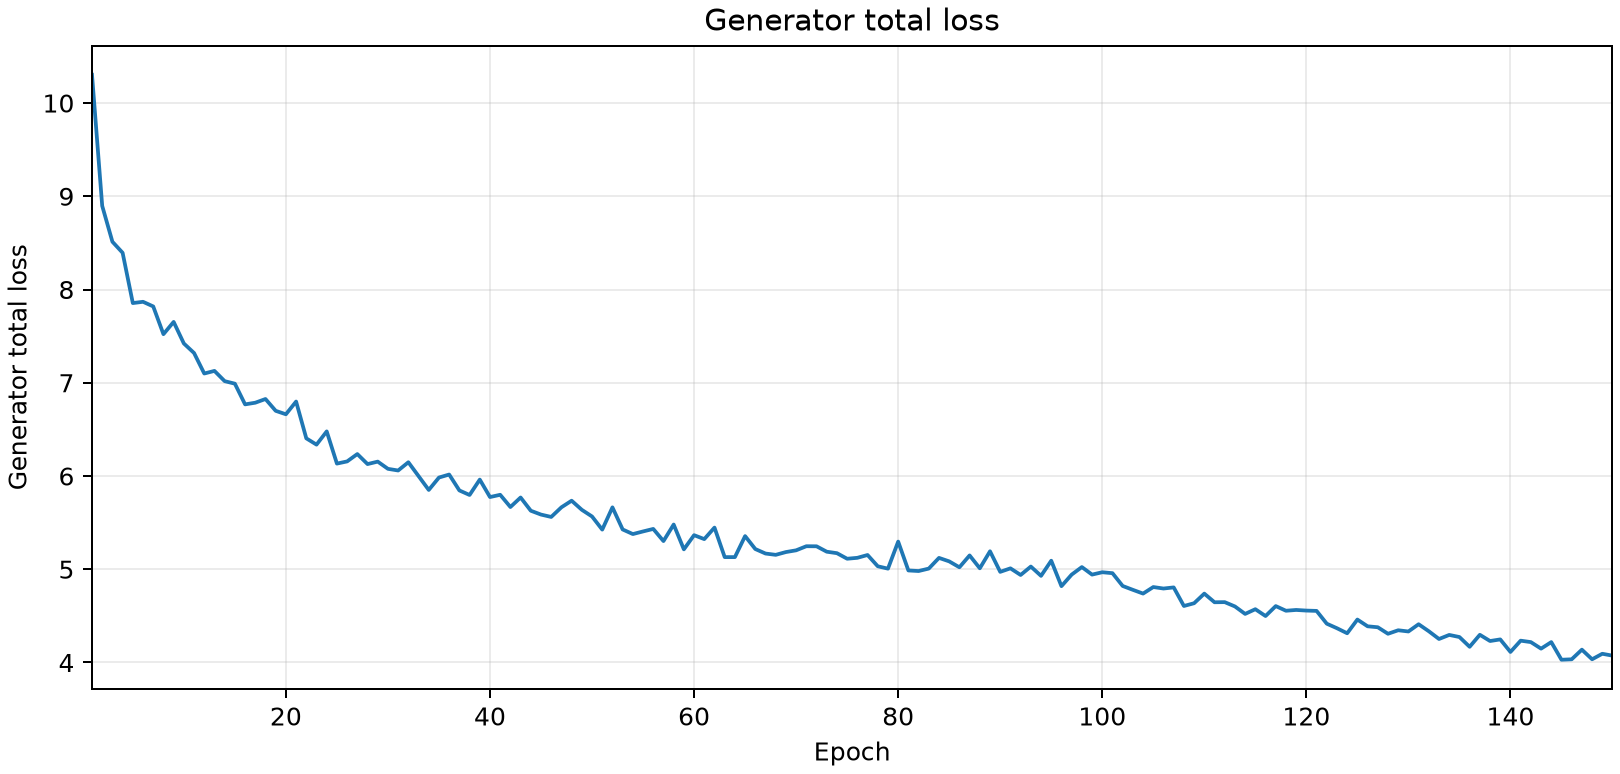

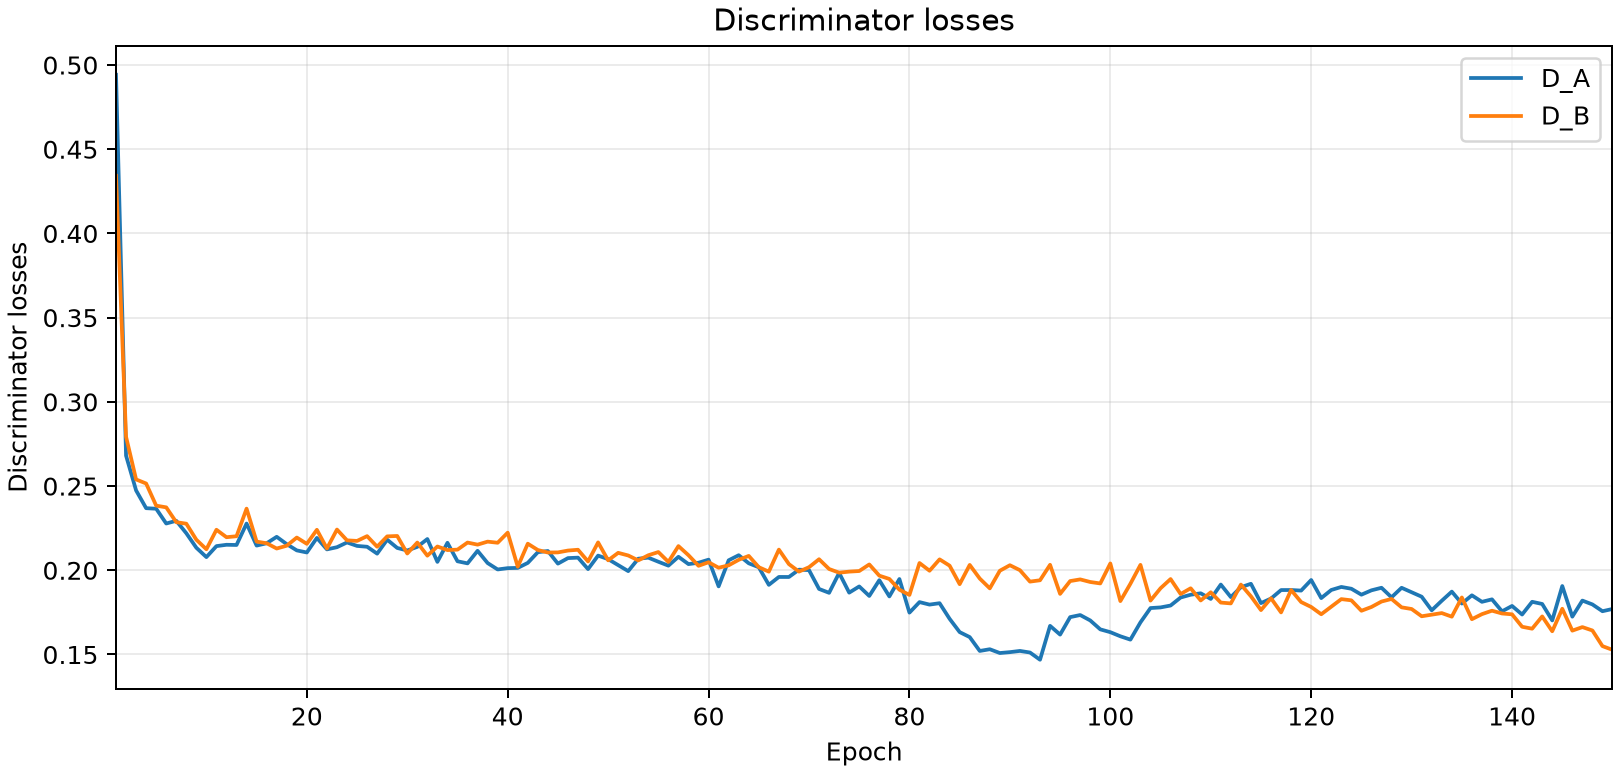

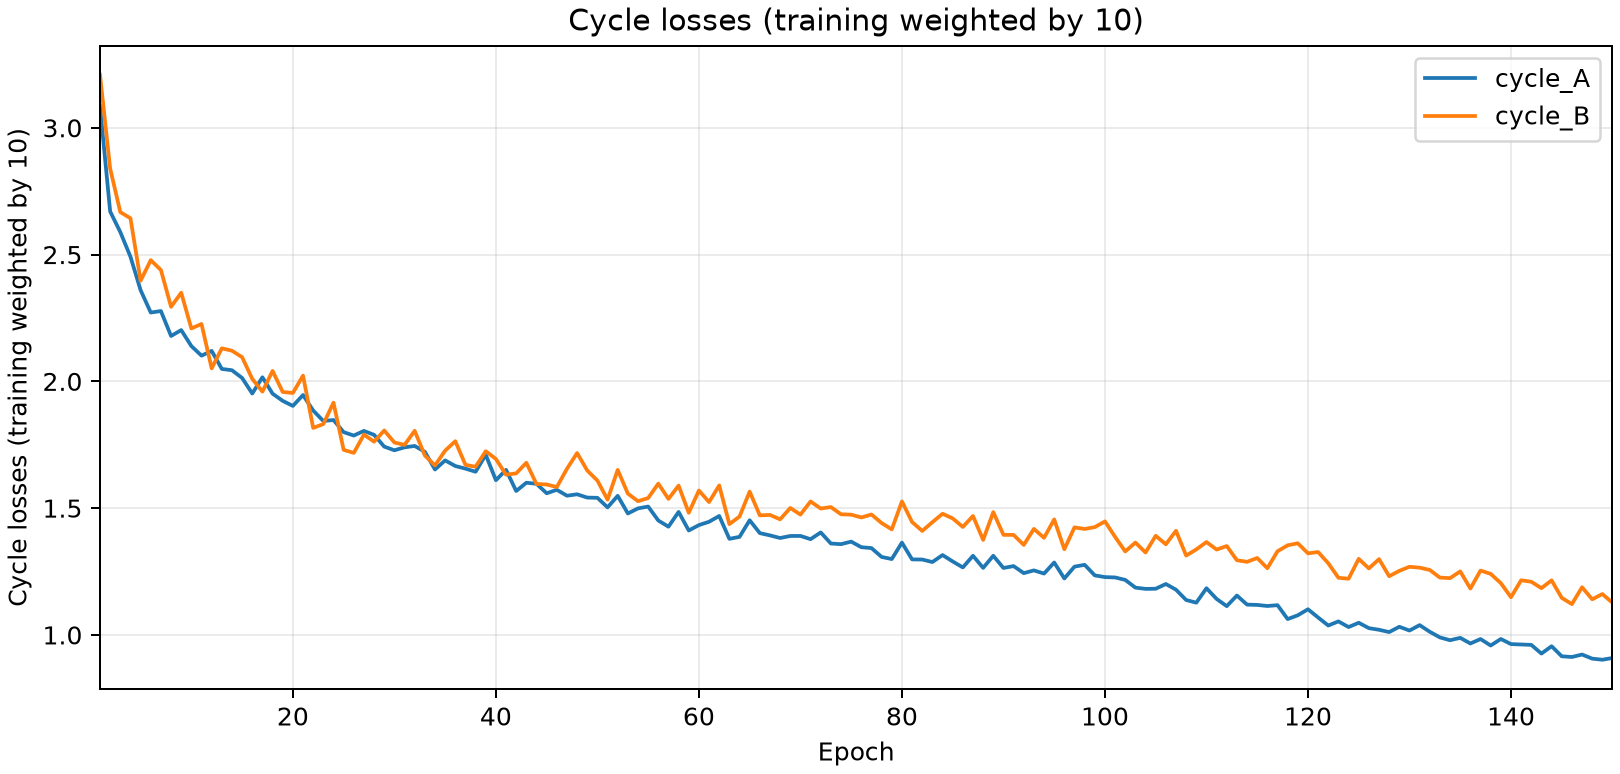

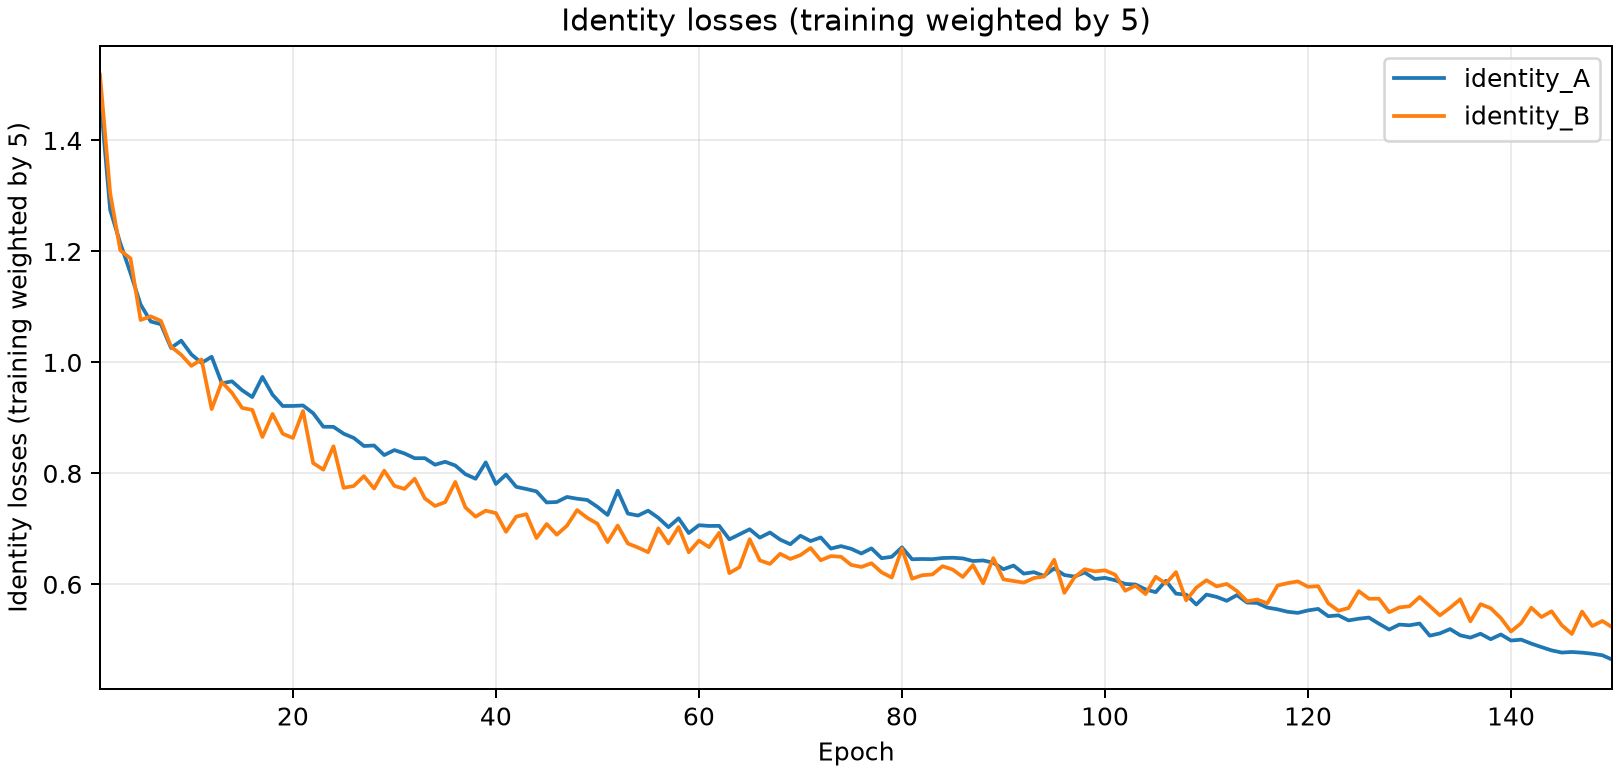

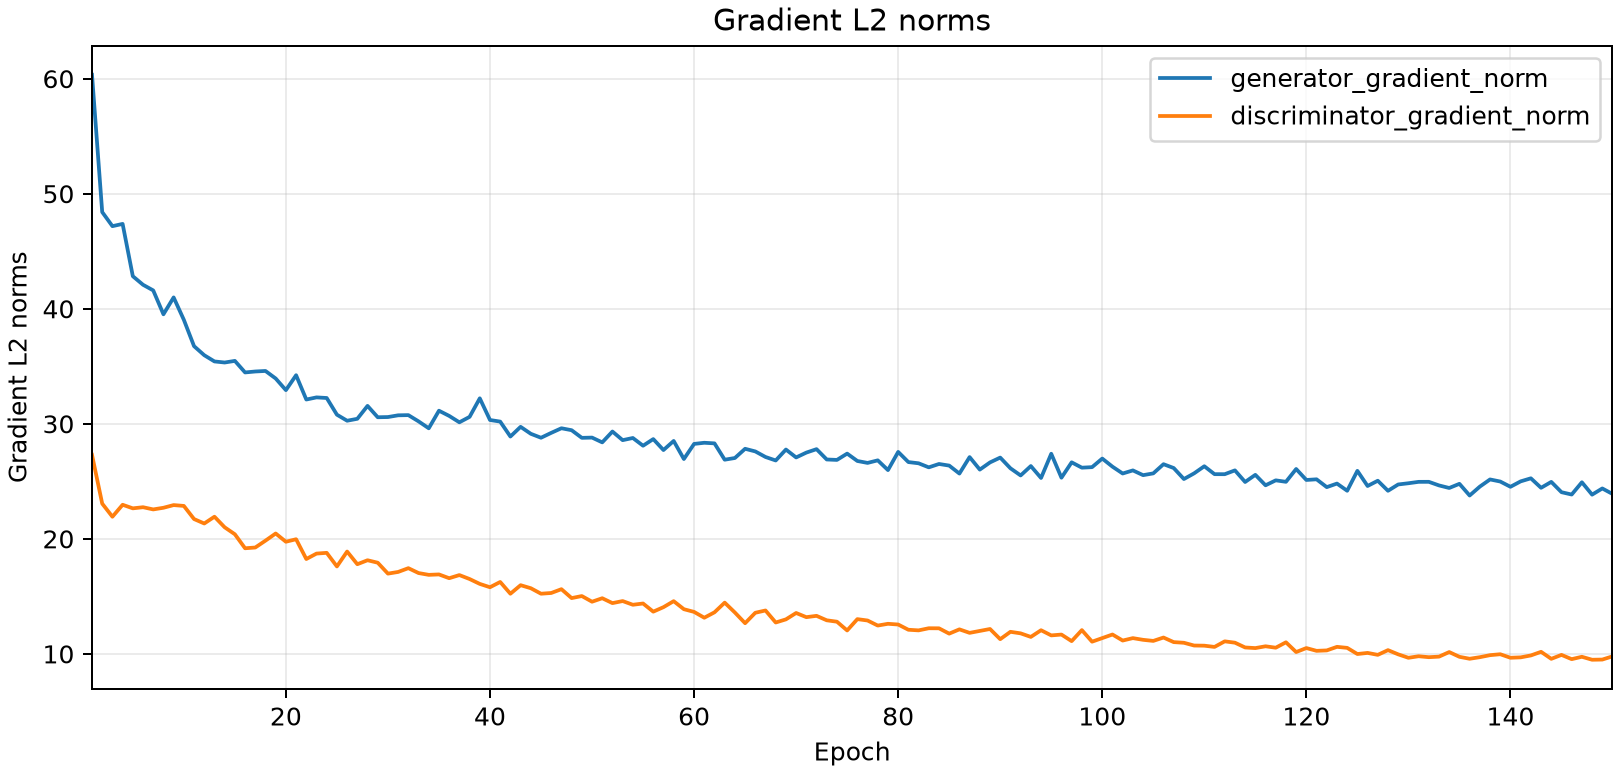

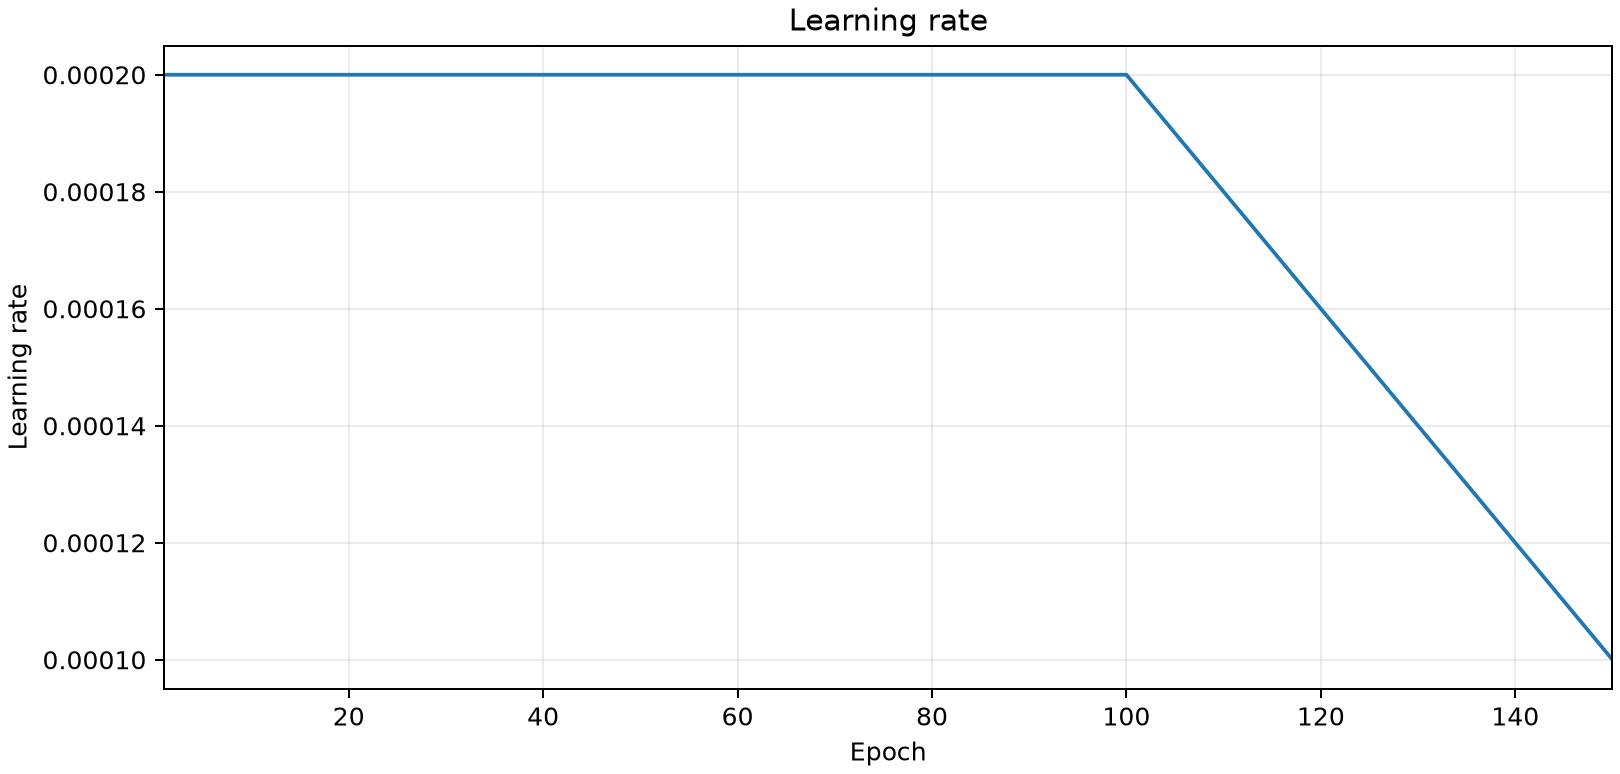

In [14]:
plot_paths = fm.make_plots(ctx)
print("\n".join(plot_paths))


## Final metric tables

Official FID/MiFID remain unchanged. Human audit/agreement and Kaggle fields are literal PENDING.


In [15]:
wide_table,long_table = fm.build_reports(ctx,kid,pr,cosine,cycle)
display(wide_table.T.rename(columns={0:"value"}))
display(long_table)
fm.document_protocol(ctx)
print("CSV evidence:",(fm.OUT_REL/"automated_metrics_epoch150.csv").as_posix(),
      (fm.OUT_REL/"full_metrics_report.csv").as_posix())


Saved tidy metrics and long-form report; human audit/agreement and Kaggle remain PENDING.
Saved factual evaluation_protocol.md with definitions, exact reuse, sample policy, versions and evidence paths.
CSV evidence: naveen/outputs_repro/final_metrics_epoch150/automated_metrics_epoch150.csv naveen/outputs_repro/final_metrics_epoch150/full_metrics_report.csv


,value
checkpoint,naveen/checkpoints_repro/repro_20261002T030447...
epoch,150
global_step,45000
FID_A2B,109.489139
MiFID_A2B,0.431104
FID_B2A,105.867864
MiFID_B2A,0.413123
submission_FID,107.678501
submission_MiFID,0.422113
KID_A2B_mean,0.025089


,metric,direction,value,units,checkpoint,protocol,evidence_file
0,FID_A2B,A2B,109.489139,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
1,MiFID_A2B,A2B,0.431104,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
2,FID_B2A,B2A,105.867864,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
3,MiFID_B2A,B2A,0.413123,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
4,submission_FID,all,107.678501,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
5,submission_MiFID,all,0.422113,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Existing official instructor result; not recom...,naveen/outputs_repro/evaluation/epoch_150/metr...
6,KID_A2B_mean,A2B,0.025089,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Unbiased degree-3 polynomial MMD; gamma=1/2048...,naveen/outputs_repro/final_metrics_epoch150/ki...
7,content_cosine_A2B_mean,A2B,0.828442,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Input vs same-filename existing translation; i...,naveen/outputs_repro/final_metrics_epoch150/co...
8,KID_A2B_std,A2B,0.002984,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Unbiased degree-3 polynomial MMD; gamma=1/2048...,naveen/outputs_repro/final_metrics_epoch150/ki...
9,content_cosine_A2B_std,A2B,0.075112,unitless,naveen/checkpoints_repro/repro_20261002T030447...,Input vs same-filename existing translation; i...,naveen/outputs_repro/final_metrics_epoch150/co...


## Validation and hashes

Finite metrics, exact sample counts, readable artifacts, unchanged protected hashes. Notebook SHA256 is recorded after executed outputs are saved.


In [16]:
fm.validate_outputs(ctx)
print("Executed evidence notebook:",fm.FINAL_NB_REL.as_posix())
print("Protocol:",(fm.OUT_REL/"evaluation_protocol.md").as_posix())
print("Errors:",ctx["errors"])


Validation passed: finite metrics, exact samples, readable CSVs/plots, protected file hashes unchanged.
9cc42d24ca52fd53d3ba1b690c92a5fb0fd4eb8a27dfd087f86e030a3ae24152 naveen/checkpoints_repro/repro_20261002T030447909094Z_57cacd34/epoch_150.pt
769bdef623ec8ec0e2899ec2d7fed1afa87bda0faec74b7a60c1de9a77761c1e naveen/outputs_repro/final_metrics_epoch150/automated_metrics_epoch150.csv
28aecd5f26ab15a91d7df6df70bca7d43f658f263b2e097a529998d4aa601b99 naveen/outputs_repro/final_metrics_epoch150/full_metrics_report.csv
Final notebook SHA256 is recorded by the executor after saving its executed outputs.
Executed evidence notebook: naveen/src/Task3_Final_Metrics_Epoch150.ipynb
Protocol: naveen/outputs_repro/final_metrics_epoch150/evaluation_protocol.md
Errors: []
